# PPO from Scratch on CartPole-v1

This notebook runs the SimWorld Option A submission: PPO implemented from scratch with PyTorch and Gymnasium. It uses the repository code in `src/ppo_cartpole.py`, trains on `CartPole-v1`, saves logs/curves, and evaluates the final policy over 100 episodes.

## 1. Setup

If this notebook is opened directly in Colab without the rest of the repository, fill in `REPO_URL` below and run the clone cell. If you opened it from a cloned repository, leave `REPO_URL` empty and continue.

In [20]:
REPO_URL = 'https://github.com/0ozcharles/simworld-ppo-cartpole.git'
REPO_DIR = 'simworld-ppo-cartpole'

from pathlib import Path

if REPO_URL:
    if Path('src/ppo_cartpole.py').exists():
        !git pull --ff-only
    elif Path(REPO_DIR).exists():
        %cd {REPO_DIR}
        !git pull --ff-only
    else:
        !git clone {REPO_URL} {REPO_DIR}
        %cd {REPO_DIR}

assert Path('src/ppo_cartpole.py').exists(), 'Run this notebook from the repository root or set REPO_URL above.'

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.02 KiB | 1.02 MiB/s, done.
From https://github.com/0ozcharles/simworld-ppo-cartpole
   8841b62..232b2d6  main       -> origin/main
Updating 8841b62..232b2d6
Fast-forward
 src/ppo_cartpole.py | 7 +------
 1 file changed, 1 insertion(+), 6 deletions(-)


In [21]:
!pip -q install -r requirements.txt

## 2. Train PPO

The default settings are tuned for `CartPole-v1` and should run on free Colab. GPU is optional for this environment.

In [22]:
import inspect
import importlib
import sys
sys.path.append('.')

import src.ppo_cartpole as ppo_cartpole
ppo_cartpole = importlib.reload(ppo_cartpole)
PPOConfig = ppo_cartpole.PPOConfig
train = ppo_cartpole.train

assert 'target_kl' in inspect.signature(PPOConfig).parameters, 'The runtime is using an older src/ppo_cartpole.py. Restart the runtime or re-run the setup cell to pull the latest code.'

config = PPOConfig(
    env_id='CartPole-v1',
    seed=42,
    total_timesteps=1_000_000,
    num_envs=8,
    num_steps=256,
    update_epochs=4,
    learning_rate=3.0e-4,
    ent_coef=0.0,
    target_kl=0.03,
    eval_episodes=100,
    eval_interval=10,
    eval_progress_episodes=10,
    output_dir='runs',
    device='auto',
)

summary = train(config)

update=001 step=002048 episodes=0096 last100=19.3 sps=3153
update=005 step=010240 episodes=0427 last100=23.4 sps=3302
update=010 step=020480 episodes=0761 last100=34.9 sps=2319
update=015 step=030720 episodes=0967 last100=49.3 sps=2400
update=020 step=040960 episodes=1117 last100=68.5 sps=2585
update=025 step=051200 episodes=1258 last100=78.4 sps=2635
update=030 step=061440 episodes=1381 last100=79.8 sps=2723
update=035 step=071680 episodes=1482 last100=106.5 sps=2797
update=040 step=081920 episodes=1613 last100=66.6 sps=2867
update=045 step=092160 episodes=1722 last100=97.7 sps=2854
update=050 step=102400 episodes=1769 last100=144.2 sps=2886
update=055 step=112640 episodes=1859 last100=122.6 sps=2930
update=060 step=122880 episodes=1920 last100=117.9 sps=2965
update=065 step=133120 episodes=2002 last100=127.0 sps=2966
update=070 step=143360 episodes=2103 last100=107.3 sps=2982
update=075 step=153600 episodes=2183 last100=110.9 sps=3006
update=080 step=163840 episodes=2259 last100=131.

{'run_dir': 'runs/cartpole-v1_ppo_seed42_1780361646',
 'episodes': 4018,
 'last_100_train_return': 139.29,
 'evaluation': {'episodes': 100.0,
  'mean_return': 500.0,
  'std_return': 0.0,
  'min_return': 500.0,
  'max_return': 500.0}}

## 3. Inspect Training Curve

Training rollout curve:


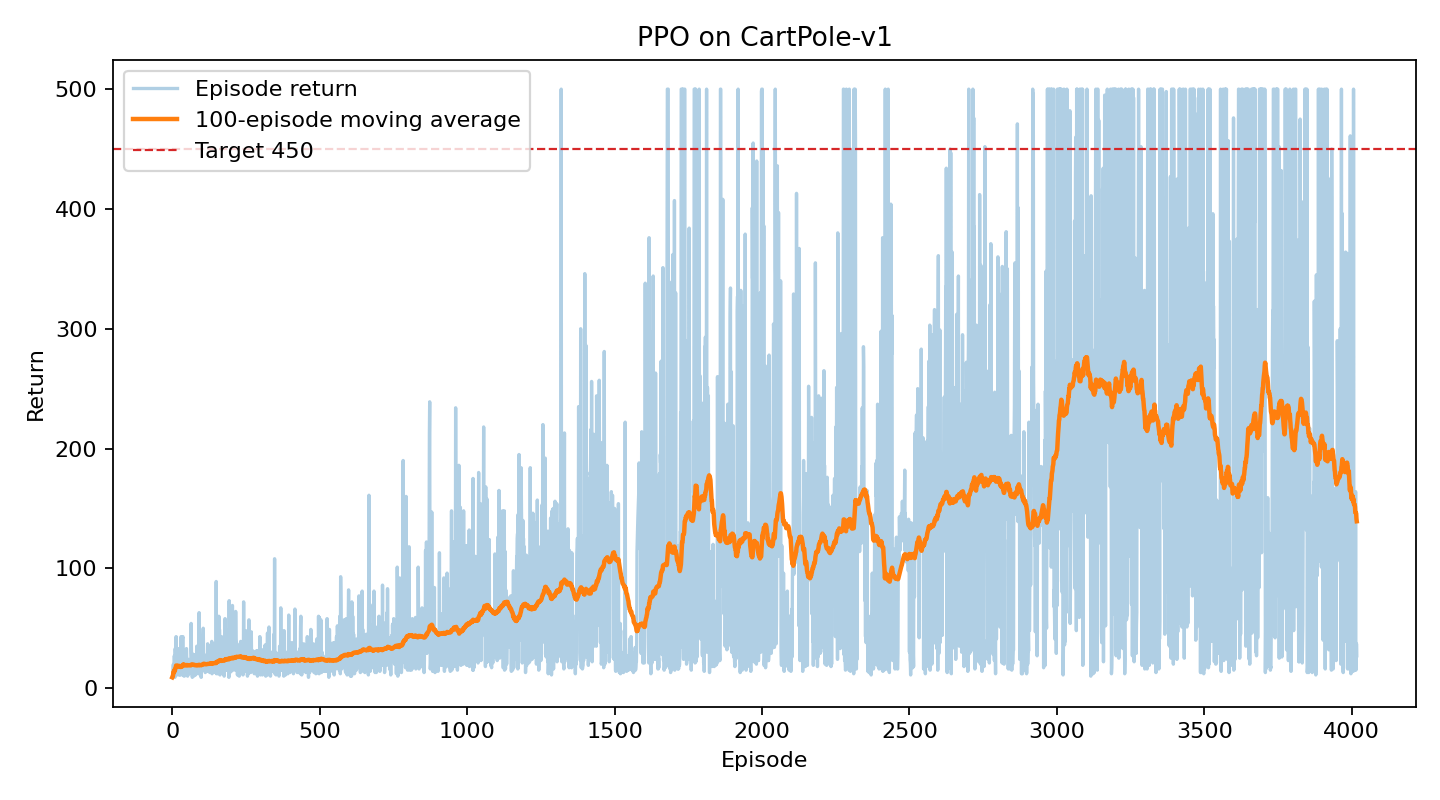

Final deterministic evaluation curve:
evaluation_curve.png was not generated, but final metrics are shown below.


In [23]:
from IPython.display import Image, display
import json
import matplotlib.pyplot as plt

training_curve_path = Path(summary['run_dir']) / 'reward_curve.png'
eval_progress_curve_path = Path(summary['run_dir']) / 'eval_progress_curve.png'
evaluation_curve_path = Path(summary['run_dir']) / 'evaluation_curve.png'

if not evaluation_curve_path.exists():
    evaluation_json = Path(summary['run_dir']) / 'evaluation.json'
    evaluation = json.loads(evaluation_json.read_text()) if evaluation_json.exists() else summary.get('evaluation', {})
    episode_returns = evaluation.get('episode_returns', [])

    if not episode_returns:
        eval_summary = summary.get('evaluation', evaluation)
        episodes = int(eval_summary.get('episodes', 0))
        mean_return = float(eval_summary.get('mean_return', 0.0))
        min_return = float(eval_summary.get('min_return', mean_return))
        max_return = float(eval_summary.get('max_return', mean_return))
        if episodes and min_return == max_return == mean_return:
            episode_returns = [mean_return] * episodes

    if episode_returns:
        mean_return = sum(episode_returns) / len(episode_returns)
        plt.figure(figsize=(9, 5))
        plt.plot(episode_returns, marker='o', linewidth=1.5, label='Evaluation return')
        plt.axhline(mean_return, color='tab:green', linestyle='-', linewidth=2, label=f'Mean {mean_return:.1f}')
        plt.axhline(450, color='tab:red', linestyle='--', linewidth=1, label='Target 450')
        plt.xlabel('Evaluation episode')
        plt.ylabel('Return')
        plt.title('Deterministic Policy Evaluation on CartPole-v1')
        plt.legend()
        plt.tight_layout()
        plt.savefig(evaluation_curve_path, dpi=160)
        plt.close()

print('Training rollout curve:')
display(Image(filename=str(training_curve_path)))

print('Deterministic evaluation progress curve:')
if eval_progress_curve_path.exists():
    display(Image(filename=str(eval_progress_curve_path)))
else:
    print('eval_progress_curve.png was not generated.')

print('Final deterministic evaluation curve:')
if evaluation_curve_path.exists():
    display(Image(filename=str(evaluation_curve_path)))
else:
    print('evaluation_curve.png was not generated, but final metrics are shown below.')

## 4. Show Final Metrics

In [24]:
import json

print(json.dumps(summary, indent=2))
print('\nFiles generated in:', summary['run_dir'])

{
  "run_dir": "runs/cartpole-v1_ppo_seed42_1780361646",
  "episodes": 4018,
  "last_100_train_return": 139.29,
  "evaluation": {
    "episodes": 100.0,
    "mean_return": 500.0,
    "std_return": 0.0,
    "min_return": 500.0,
    "max_return": 500.0
  }
}

Files generated in: runs/cartpole-v1_ppo_seed42_1780361646
